# Modulación BPSK

En esta sección se analiza la modulación BPSK (Binary Phase Shift Keying) y se representa la señal modulada para una secuencia de bits determinada.

Se utilizarán funciones auxiliares definidas en `tp1_utils.py` para generar las señales y representar sus características en los dominios temporal y frecuencial.

In [ ]:
# Ejecutar estas lineas por única vez para instalar las librerías
# !pip install numpy
# !pip install matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path.cwd())) # Para poder importar tp1_utils.py desde el notebook

from tp1_utils import (
    generate_bits,
    bpsk_symbols,
    generate_baseband_waveform,
    generate_bpsk_waveform,
    compute_fft,
    plot_bpsk,
    plot_spectrum,
)

## Técnica de modulación

La técnica representada es **BPSK (Binary Phase Shift Keying)**, una técnica de modulación digital por desplazamiento de fase.

En BPSK se utilizan dos fases de una señal portadora, separadas 180°. Cada símbolo binario se representa mediante una de ellas.

Para la representación utilizada:

- `0` → fase `0°`
- `1` → fase `180°`

Matemáticamente, la señal puede expresarse como:

$$
s(t)=a_k\sin(2\pi f_c t)
$$

donde $a_k$ toma los valores $+1$ o $-1$ según el símbolo
transmitido.

In [3]:
bits = generate_bits("01110110")

symbols = bpsk_symbols(bits)

print("Bits:    ", bits)
print("Símbolos:", symbols)

Bits:     [0 1 1 1 0 1 1 0]
Símbolos: [ 1 -1 -1 -1  1 -1 -1  1]


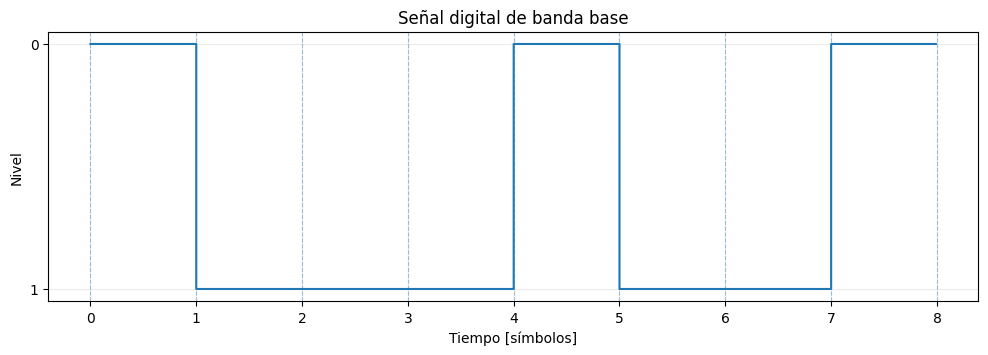

In [4]:
t_baseband, baseband = generate_baseband_waveform(
    bits,
    samples_per_symbol=100,
)

fig, ax = plt.subplots(figsize=(12, 3.5))

ax.step(
    t_baseband,
    baseband,
    where="post",
)

for i in range(len(bits) + 1):
    ax.axvline(
        i,
        linestyle="--",
        linewidth=0.8,
        alpha=0.4,
    )

ax.set_title("Señal digital de banda base")
ax.set_xlabel("Tiempo [símbolos]")
ax.set_ylabel("Nivel")

ax.set_yticks([-1, 1])
ax.set_yticklabels(["1", "0"])

ax.grid(True, alpha=0.25)
plt.show()

La secuencia

$$
01110110
$$

se transforma, mediante el mapeo BPSK adoptado, en los símbolos

$$
+1,\;-1,\;-1,\;-1,\;+1,\;-1,\;-1,\;+1.
$$

Cada símbolo determina la fase de la portadora durante el intervalo
correspondiente.

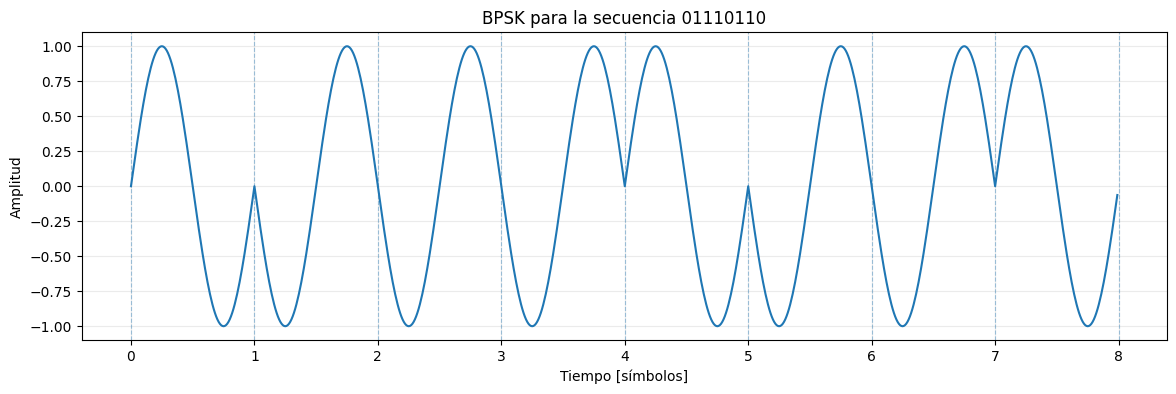

In [6]:
t, bpsk, symbols = generate_bpsk_waveform(
    bits,
    fc=1,
    samples_per_symbol=100,
)

fig, ax = plt.subplots(figsize=(14, 4))

plot_bpsk(
    bits,
    t,
    bpsk,
    samples_per_symbol=100,
    ax=ax,
)
fig.savefig(
    "../assets/tp1-bpsk_01110110.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()